In [5]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import tifffile as tiff
import os
import sys
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Cross-predict

Loads a model checkpoint saved by `features.ipynb` (`models.gnn.save_model`, under
`../results/models/{img_name}_{gnn|gat}.pt`) and evaluates it against a cell table --
by default the same image it was trained on (a mechanics check), but point
`EVAL_IMG_NAME` at a DIFFERENT image's `../data/training/{name}.csv` to test whether
the model actually generalizes across images, rather than just memorizing this one.

The checkpoint carries everything needed to re-apply the model correctly: the exact
`x_cols`/`y_cols`, the fitted scalers (REUSED, not refit -- `models.gnn.
apply_prediction_data`), and the radius-graph params. Cross-image comparisons only
make sense between images sharing the same marker panel (channel names) as whatever
the model was trained on.

In [20]:
# TRAIN_IMG_NAME = '20260717T120225_pA_Activin_D4_48hr_W0001'  # which saved checkpoint to load
# TRAIN_IMG_NAME = '20260521T171725_pA-BMP4_G3_44hr_induction_W0001'
TRAIN_IMG_NAME = 'W8_pattern1_Sox17_Brachyury'
# TRAIN_IMG_NAME = 'W10_Cultrex_mask7'
MODEL_TYPE = 'gnn'  # 'gnn' | 'gat' -- must match how the checkpoint was saved

# EVAL_IMG_NAME = 'W16_Cultrex_mask6' 
EVAL_IMG_NAME = 'W8_pattern1_Sox17_Brachyury'
PREDICT_TYPE = '_mask_xBMP4_ySox17_cropped' # should be '' or '_xX_yY_cropped' format
FIGURE_DIR = f'../results/figures/{TRAIN_IMG_NAME}/{PREDICT_TYPE.removeprefix("_")}/cross_predict'
os.makedirs(FIGURE_DIR, exist_ok=True) 

In [21]:
from models.gnn import load_model, apply_prediction_data, predict_df, border_mask, IFPredictor
from models.gat import IFPredictorGAT

model_cls = IFPredictor if MODEL_TYPE == 'gnn' else IFPredictorGAT
checkpoint_path = f'../results/models/{TRAIN_IMG_NAME}{PREDICT_TYPE}_{MODEL_TYPE}.pt'
model, checkpoint = load_model(checkpoint_path, model_cls)

print(f'Loaded {checkpoint_path}')
print("x_cols (self + neighbors, via the graph's self-loop):", checkpoint['x_cols'])
print('y_cols (predicted):', checkpoint['y_cols'])
print('radius:', checkpoint['radius'])

Loaded ../results/models/W8_pattern1_Sox17_Brachyury_mask_xBMP4_ySox17_cropped_gnn.pt
x_cols (self + neighbors, via the graph's self-loop): ['BMP4_mean']
y_cols (predicted): ['Sox17_mean']
radius: 50


In [22]:
eval_cell_df = pd.read_parquet(f'../data/stitched/{EVAL_IMG_NAME}_features.parquet')
eval_out = tiff.imread(f'../data/stitched/{EVAL_IMG_NAME}.tif')

if 'mask' in PREDICT_TYPE:
    input_cols = set(checkpoint['x_cols'])
    for col in input_cols:
        bool_col = col.replace('_mean', '+')
        if bool_col in eval_cell_df.columns:
            eval_cell_df[col] = eval_cell_df[bool_col].astype(float)

eval_centroids = eval_cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)

all_expected_cols = set(checkpoint['x_cols']) | set(checkpoint['y_cols'])
needed = [c for c in all_expected_cols if c not in eval_cell_df.columns]
if 'local_density' in needed:
    density_radius = checkpoint.get('density_radius') or checkpoint['radius']
    eval_cell_df['local_density'] = local_density(eval_centroids, radius=density_radius)
    needed.remove('local_density')
if needed:
    raise ValueError(f'eval_cell_df is missing columns the checkpoint expects: {needed}')

border_radius = max(checkpoint['radius'], checkpoint.get('density_radius') or 0)
eval_is_border = border_mask(eval_centroids, eval_out.shape[1:], border_radius)
eval_mask = torch.from_numpy(~eval_is_border)
print(f"{eval_is_border.sum()} / {len(eval_cell_df)} cells within {border_radius}px of the border -- excluded from eval")

eval_data = apply_prediction_data(eval_cell_df, checkpoint)
print(f"{len(eval_cell_df)} cells, {eval_data['edge_index'].shape[1]} directed edges incl. self-loops")

3150 / 111511 cells within 50px of the border -- excluded from eval
111511 cells, 2257045 directed edges incl. self-loops


,R2,MAE
feature,,
Sox17_mean,-0.540938,0.169497


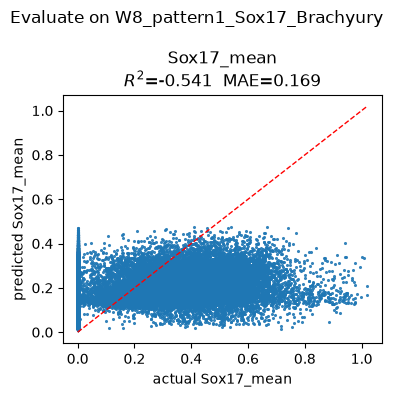

In [23]:
from tools.morphology import r2_table, plot_pred_vs_actual
pred_df, true_df = predict_df(model, eval_data, eval_mask, eval_cell_df.index, y_scaler=None)
r2 = r2_table(true_df, pred_df)
display(r2)

fig_pred  = plot_pred_vs_actual(true_df, pred_df, title=f'Evaluate on {EVAL_IMG_NAME}')
plt.show()

fig_pred.savefig(f'{FIGURE_DIR}/{MODEL_TYPE}_{EVAL_IMG_NAME}_r2.png', dpi=300, bbox_inches='tight')

In [24]:
y_cols = list(pred_df.columns)
centroids_eval = eval_cell_df.loc[pred_df.index, ['centroid_x', 'centroid_y']]

data = centroids_eval.copy()
for col in y_cols:
    data[f'{col} (actual)'] = true_df[col].values
    data[f'{col} (predicted)'] = pred_df[col].values

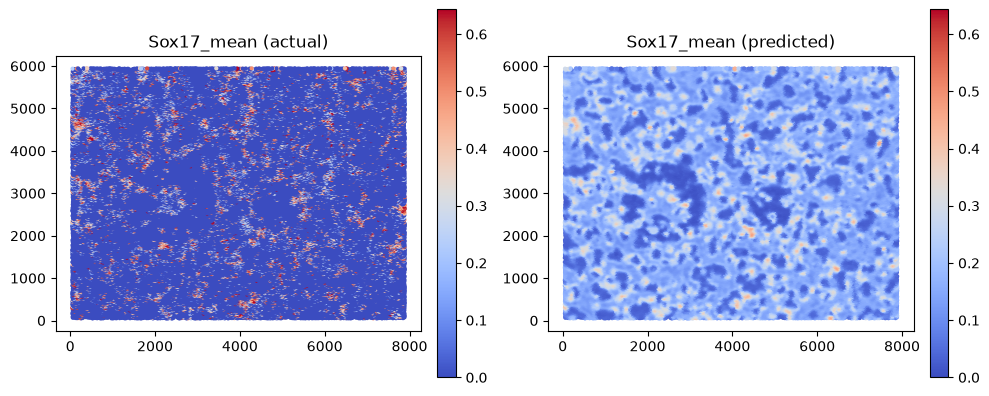

In [25]:
plot_cols = [x for x in data.columns if 'centroid' not in x]
fig, axs = plt.subplots(1, len(plot_cols), figsize=(5 * len(plot_cols), 5))
axs = axs.flatten()

for i, col in enumerate(plot_cols):
    ax = axs[i]

    base_col = col.split(' (')[0]
    vmin, vmax = np.percentile(data[f'{base_col} (actual)'], [1, 99])
    sc = ax.scatter(
        data['centroid_x'], data['centroid_y'],
        c=data[col], 
        cmap='coolwarm',
        s=4, vmin=vmin, vmax=vmax,
    )
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()

fig.savefig(f'{FIGURE_DIR}/{MODEL_TYPE}_{EVAL_IMG_NAME}_spatial.png', dpi=300)
plt.show()

In [26]:
data[[x for x in data.columns if 'centroid' not in x]].corr(method='spearman')

,Sox17_mean (actual),Sox17_mean (predicted)
Sox17_mean (actual),1.000000,0.226004
Sox17_mean (predicted),0.226004,1.000000


In [27]:
data[[x for x in data.columns if 'centroid' not in x]].corr(method='pearson')

,Sox17_mean (actual),Sox17_mean (predicted)
Sox17_mean (actual),1.00000,0.23447
Sox17_mean (predicted),0.23447,1.00000


### Evaluate on a jittered version of the eval image

Rather than training on jittered cells, this reuses the `model`/`checkpoint` already
loaded above (trained on real, unjittered data) and evaluates it against a JITTERED
version of `EVAL_IMG_NAME`'s cells (`tools.simulated.jitter_real_cells`) -- same real
marker values, just slightly different XY positions/local density. Compares directly
against the `r2` computed above on the real (unjittered) eval cells, to see how much a
shift in local density alone (with nothing else about the cells changed) degrades --
or doesn't -- the model's predictions.

In [28]:
from tools.simulated import jitter_real_cells

JITTER_STD = 30.1 
JITTER_SEED = 0

JITTER_FIGURE_DIR = f'{FIGURE_DIR}/jittered_std{JITTER_STD}'
os.makedirs(JITTER_FIGURE_DIR, exist_ok=True)

eval_label_mask = np.load(f'../data/stitched/{EVAL_IMG_NAME}.npy')
jittered_label_mask, jittered_eval_cell_df = jitter_real_cells(
    eval_label_mask, eval_cell_df, position_jitter_std=JITTER_STD, seed=JITTER_SEED,
)
print(f'{len(eval_cell_df)} real cells -> {len(jittered_eval_cell_df)} after jitter')

jittered_centroids = jittered_eval_cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)

jittered_needed = [c for c in all_expected_cols if c not in jittered_eval_cell_df.columns]
if 'local_density' in jittered_needed:
    jit_density_radius = checkpoint.get('density_radius') or checkpoint['radius']
    jittered_eval_cell_df['local_density'] = local_density(jittered_centroids, radius=jit_density_radius)
    jittered_needed.remove('local_density')
if jittered_needed:
    raise ValueError(f'jittered_eval_cell_df is missing columns the checkpoint expects: {jittered_needed}')

jittered_is_border = border_mask(jittered_centroids, jittered_label_mask.shape, border_radius)
jittered_eval_mask = torch.from_numpy(~jittered_is_border)
print(f"{jittered_is_border.sum()} / {len(jittered_eval_cell_df)} cells within {border_radius}px of the border -- excluded from eval")

jittered_eval_data = apply_prediction_data(jittered_eval_cell_df, checkpoint)
print(f"{len(jittered_eval_cell_df)} cells, {jittered_eval_data['edge_index'].shape[1]} directed edges")

jitter_real_cells: 502 / 111511 cells lost all pixels at position_jitter_std=30.1 and were dropped
111511 real cells -> 111009 after jitter
2623 / 111009 cells within 50px of the border -- excluded from eval
111009 cells, 2244449 directed edges


before  -- mean=19.24, std=5.16
after   -- mean=19.22, std=5.61
per-cell delta -- mean=-0.05, std=4.38


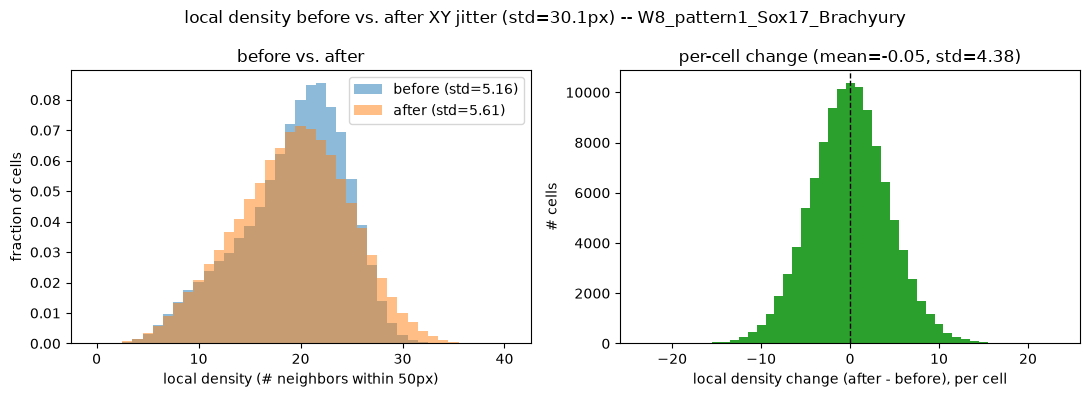

In [29]:
from tools.morphology import local_density

DENSITY_RADIUS = 50  # px -- matches jitter.ipynb's DENSITY_RADIUS

before_density = pd.Series(
    local_density(eval_cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32), radius=DENSITY_RADIUS),
    index=eval_cell_df.index,
)
after_density = pd.Series(
    local_density(jittered_eval_cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32), radius=DENSITY_RADIUS),
    index=jittered_eval_cell_df.index,
)
# Per-cell change, restricted to cells that survived the jitter (see jitter_real_cells's
# drop-count print above) -- a dropped cell has no "after" value to diff against.
density_diff = after_density.loc[jittered_eval_cell_df.index] - before_density.loc[jittered_eval_cell_df.index]

print(f'before  -- mean={before_density.mean():.2f}, std={before_density.std():.2f}')
print(f'after   -- mean={after_density.mean():.2f}, std={after_density.std():.2f}')
print(f'per-cell delta -- mean={density_diff.mean():.2f}, std={density_diff.std():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
bins = np.arange(0, max(before_density.max(), after_density.max()) + 2) - 0.5
ax.hist(before_density, bins=bins, alpha=0.5, label=f'before (std={before_density.std():.2f})', density=True)
ax.hist(after_density, bins=bins, alpha=0.5, label=f'after (std={after_density.std():.2f})', density=True)
ax.set_xlabel(f'local density (# neighbors within {DENSITY_RADIUS}px)')
ax.set_ylabel('fraction of cells')
ax.set_title('before vs. after')
ax.legend()

ax = axes[1]
diff_bound = np.abs(density_diff).max()
diff_bins = np.arange(-diff_bound, diff_bound + 2) - 0.5
ax.hist(density_diff, bins=diff_bins, color='C2')
ax.axvline(0, color='k', linestyle='--', linewidth=1)
ax.set_xlabel('local density change (after - before), per cell')
ax.set_ylabel('# cells')
ax.set_title(f'per-cell change (mean={density_diff.mean():.2f}, std={density_diff.std():.2f})')

fig.suptitle(f'local density before vs. after XY jitter (std={JITTER_STD}px) -- {EVAL_IMG_NAME}')
fig.tight_layout()
fig.savefig(f'{JITTER_FIGURE_DIR}/density_before_after.png', dpi=300, bbox_inches='tight')
plt.show()

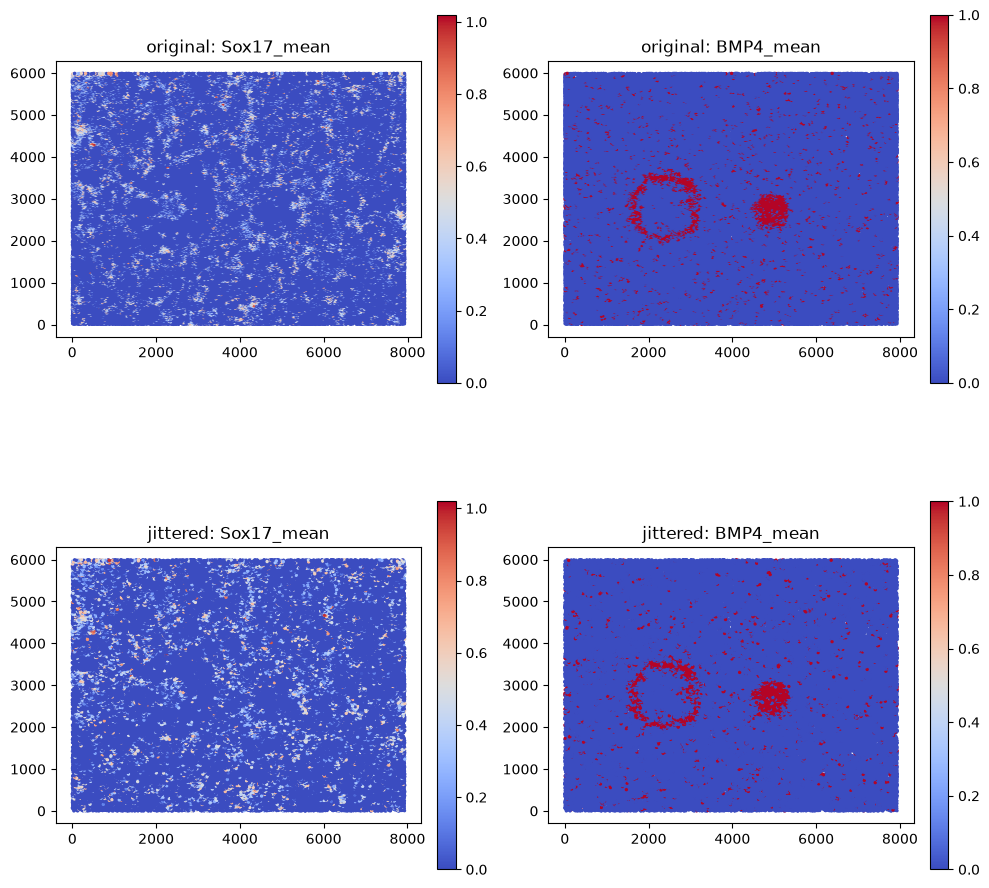

In [30]:
# Same "checkpoint's own scaled input, original vs. jittered" comparison as jitter.ipynb's
# `build_scaled_feature_frame` section -- but reusing `eval_data`/`jittered_eval_data`
# (already built above via `apply_prediction_data`, i.e. the checkpoint's OWN fitted
# scalers) instead of refitting fresh ones, since here there's a specific trained model
# whose actual input we want to see, not a from-scratch comparison.
def _scaled_feature_frame(pred_data, cell_df):
    frame = pd.DataFrame(pred_data['y'], columns=pred_data['y_cols'])
    for i, col in enumerate(pred_data['x_cols']):
        frame[col] = pred_data['x'][:, i]
    frame['centroid_x'] = cell_df['centroid_x'].values
    frame['centroid_y'] = cell_df['centroid_y'].values
    return frame

feat_orig = _scaled_feature_frame(eval_data, eval_cell_df)
feat_jit = _scaled_feature_frame(jittered_eval_data, jittered_eval_cell_df)

feat_cols = [x for x in feat_jit.columns if 'centroid' not in x]
fig, axs = plt.subplots(2, len(feat_cols), figsize=(5 * len(feat_cols), 10), squeeze=False)

for row, (row_label, feat) in enumerate([('original', feat_orig), ('jittered', feat_jit)]):
    for i, col in enumerate(feat_cols):
        ax = axs[row, i]
        # Shared vmin/vmax per column across both rows, so color intensity is comparable.
        vmin = min(feat_orig[col].min(), feat_jit[col].min())
        vmax = max(feat_orig[col].max(), feat_jit[col].max())
        sc = ax.scatter(
            feat['centroid_x'], feat['centroid_y'],
            c=feat[col], cmap='coolwarm', vmin=vmin, vmax=vmax,
            s=2,
        )
        ax.set_title(f'{row_label}: {col}', fontsize=12)
        ax.set_xlabel(None)
        ax.set_ylabel(None)
        ax.set_aspect('equal', adjustable='box')
        fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(f'{JITTER_FIGURE_DIR}/features_orig_vs_jittered.png', dpi=300)
plt.show()

,R2,MAE
feature,,
Sox17_mean,-0.922341,0.191049


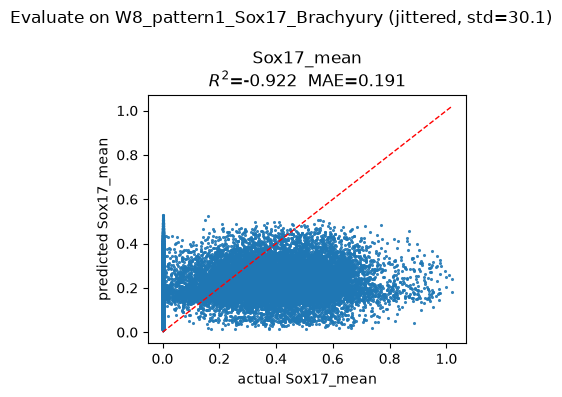

In [31]:
jit_pred_df, jit_true_df = predict_df(model, jittered_eval_data, jittered_eval_mask, jittered_eval_cell_df.index, y_scaler=None)
jit_r2 = r2_table(jit_true_df, jit_pred_df)
display(jit_r2)

fig_jit_pred = plot_pred_vs_actual(jit_true_df, jit_pred_df, title=f'Evaluate on {EVAL_IMG_NAME} (jittered, std={JITTER_STD})')
plt.show()

fig_jit_pred.savefig(f'{JITTER_FIGURE_DIR}/{MODEL_TYPE}_{EVAL_IMG_NAME}_r2.png', dpi=300, bbox_inches='tight')

In [32]:
comparison = pd.concat({'original (unjittered)': r2, f'jittered (std={JITTER_STD})': jit_r2}, axis=1)
display(comparison)

original (unjittered)           jittered (std=30.1)          
                              R2       MAE                  R2       MAE
feature                                                                 
Sox17_mean             -0.540938  0.169497           -0.922341  0.191049

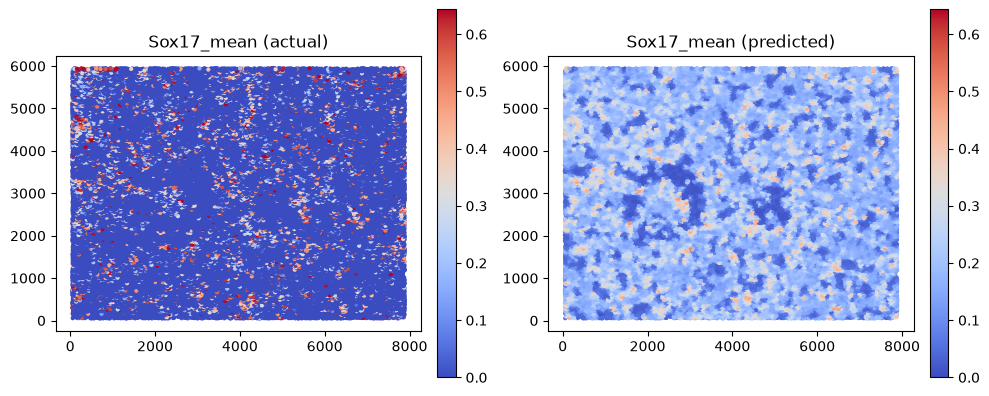

In [33]:
jit_y_cols = list(jit_pred_df.columns)
jit_centroids_eval = jittered_eval_cell_df.loc[jit_pred_df.index, ['centroid_x', 'centroid_y']]

jit_data = jit_centroids_eval.copy()
for col in jit_y_cols:
    jit_data[f'{col} (actual)'] = jit_true_df[col].values
    jit_data[f'{col} (predicted)'] = jit_pred_df[col].values

jit_plot_cols = [x for x in jit_data.columns if 'centroid' not in x]
fig, axs = plt.subplots(1, len(jit_plot_cols), figsize=(5 * len(jit_plot_cols), 5))
axs = axs.flatten()

for i, col in enumerate(jit_plot_cols):
    ax = axs[i]

    base_col = col.split(' (')[0]
    vmin, vmax = np.percentile(jit_data[f'{base_col} (actual)'], [1, 99])
    sc = ax.scatter(
        jit_data['centroid_x'], jit_data['centroid_y'],
        c=jit_data[col], cmap='coolwarm',
        s=4, vmin=vmin, vmax=vmax,
    )
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()

fig.savefig(f'{JITTER_FIGURE_DIR}/{MODEL_TYPE}_{EVAL_IMG_NAME}_spatial.png', dpi=300)
plt.show()